# Exercise 3: Nitrification in a Biofilm-Fluidized Bed Reactor

Nitrification is modeled as a two-step sequential oxidation:

$$\text{NH}_4^+ + O_2 \rightarrow \text{NO}_2^-$$
$$\text{NO}_2^- + O_2 \rightarrow \text{NO}_3^-$$

**Species:**
- $S_1$: NH₄⁺ (ammonium)
- $S_2$: NO₂⁻ (nitrite)
- $S_3$: NO₃⁻ (nitrate)
- $C_L$: dissolved oxygen

**Kinetics (double Monod):**
$$r_1 = v_{m1} \frac{S_1}{K_1 + S_1} \frac{C_L}{K_{O1} + C_L}$$
$$r_2 = v_{m2} \frac{S_2}{K_2 + S_2} \frac{C_L}{K_{O2} + C_L}$$

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Parameters
vm1  = 125.0   # h⁻¹, max reaction rate step 1 (NH4+ → NO2-)
vm2  =  75.0   # h⁻¹, max reaction rate step 2 (NO2- → NO3-)
K1   =   5.0   # mg/L, half-saturation S1
K2   =   3.0   # mg/L, half-saturation S2
KO1  =   0.25  # mg/L, O2 half-saturation step 1
KO2  =   0.50  # mg/L, O2 half-saturation step 2
YO1  =   3.5   # mg O2 / mg S1  (Y_O/S1)
YO2  =   1.1   # mg O2 / mg S2  (Y_O/S2)
CL_star = 8.0  # mg/L, O2 saturation concentration

# Initial conditions
S1_0  = 100.0  # mg/L  NH4+
S2_0  =   0.0  # mg/L  NO2-
S3_0  =   0.0  # mg/L  NO3-
CL_0  =   7.0  # mg/L  dissolved O2

print("Parameters loaded successfully.")

Parameters loaded successfully.


## Part (a) Concentration Balances:

For a **batch system** with oxygen transfer from gas to liquid:

$$\frac{dS_1}{dt} = -r_1$$

$$\frac{dS_2}{dt} = r_1\,\frac{Y_{O/S_1}}{Y_{O/S_2}} - r_2$$

$$\frac{dS_3}{dt} = r_2$$

$$\frac{dC_L}{dt} = k_La\,(C_L^* - C_L) - Y_{O/S_1}\,r_1 - Y_{O/S_2}\,r_2$$

- $r_1$ consumes $S_1$ and produces $S_2$; it consumes $Y_{O/S_1}\cdot r_1$ of oxygen.
- $r_2$ consumes $S_2$ and produces $S_3$; it consumes $Y_{O/S_2}\cdot r_2$ of oxygen.
- The $k_La$ term replenishes dissolved oxygen from the gas phase.

In [10]:
def reaction_rates(S1, S2, CL):

    r1 = vm1 * (S1 / (K1 + S1)) * (CL / (KO1 + CL))
    r2 = vm2 * (S2 / (K2 + S2)) * (CL / (KO2 + CL))
    return r1, r2


def odes(t, y, kLa):

    S1, S2, S3, CL = y
    # Clamp negatives (numerical safety)
    S1 = max(S1, 0.0)
    S2 = max(S2, 0.0)
    S3 = max(S3, 0.0)
    CL = max(CL, 0.0)

    r1, r2 = reaction_rates(S1, S2, CL)

    dS1 = -r1
    dS2 =  r1 * YO1 / YO2 - r2
    dS3 =  r2
    dCL =  kLa * (CL_star - CL) - YO1 * r1 - YO2 * r2

    return [dS1, dS2, dS3, dCL]


def simulate(kLa, t_end=3.0, n_points=6000):

    y0     = [S1_0, S2_0, S3_0, CL_0]
    t_span = (0, t_end)
    t_eval = np.linspace(0, t_end, n_points)
    sol = solve_ivp(odes, t_span, y0, method='BDF',
                    args=(kLa,), t_eval=t_eval,
                    rtol=1e-8, atol=1e-8)
    return sol

print("ODE system and helper functions defined.")

ODE system and helper functions defined.



## Part (b) Find k_La to Keep C_L > K_O1:

Minimum k_La to avoid oxygen limitation: ~49.3 h⁻¹


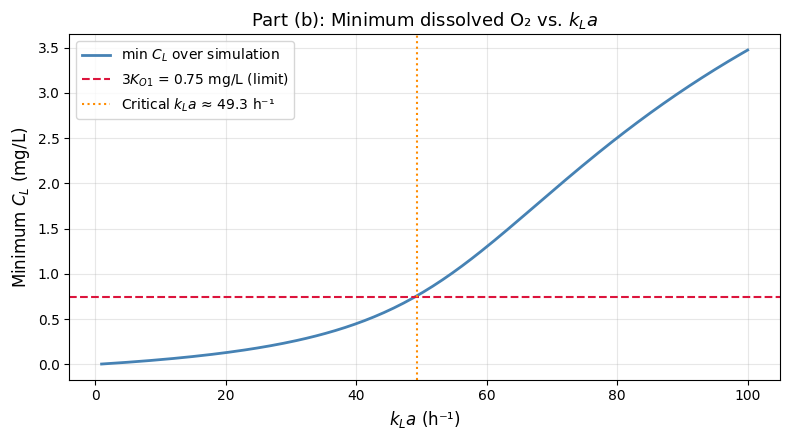


Conclusion: k_La ≥ 49.3 h⁻¹ keeps C_L above K_O1 throughout the process.


In [ ]:
kLa_values = np.linspace(1, 100, 200)   # h⁻¹
min_CL     = []

for kLa in kLa_values:
    sol = simulate(kLa, t_end=3.0)
    min_CL.append(np.min(sol.y[3]))      # index 3 = CL

min_CL = np.array(min_CL)

# critical kLa (first value where min_CL > KO1)
critical_mask  = min_CL >= 3 * KO1
kLa_critical   = kLa_values[critical_mask][0] if critical_mask.any() else None
print(f"Minimum k_La to avoid oxygen limitation: ~{kLa_critical:.1f} h⁻¹")

#Plots
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(kLa_values, min_CL, lw=2, color='steelblue', label='min $C_L$ over simulation')
ax.axhline(3 * KO1, color='crimson', ls='--', lw=1.5, label=f'$3K_{{O1}}$ = {3 * KO1} mg/L (limit)')
if kLa_critical is not None:
    ax.axvline(kLa_critical, color='darkorange', ls=':', lw=1.5,
               label=f'Critical $k_La$ ≈ {kLa_critical:.1f} h⁻¹')
ax.set_xlabel('$k_La$ (h⁻¹)', fontsize=12)
ax.set_ylabel('Minimum $C_L$ (mg/L)', fontsize=12)
ax.set_title('Part (b): Minimum dissolved O₂ vs. $k_La$', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"\nConclusion: k_La ≥ {kLa_critical:.1f} h⁻¹ keeps C_L above 3K_O1 throughout the process.")

## Part (c) Time for S1 to reach zero (no O₂ limitation) & full species plot:

S1 (NH4+) reaches ~0 mg/L at t ≈ 1.0088 h  (no O₂ limitation)


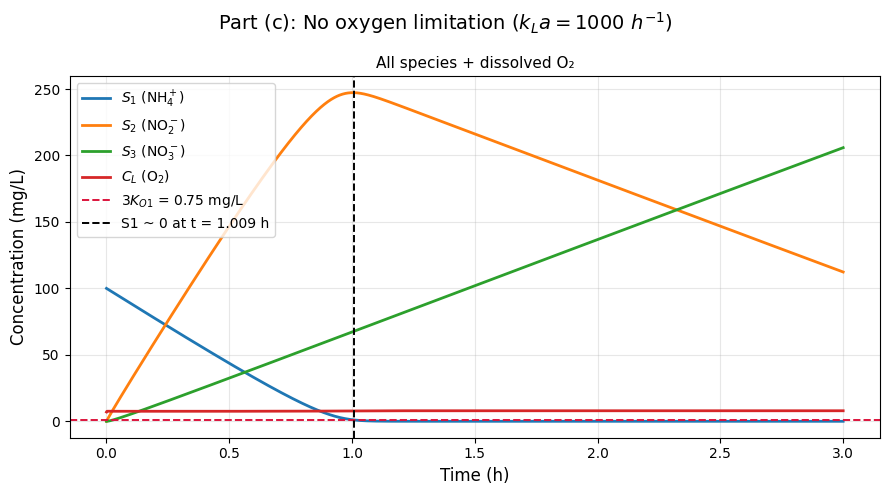

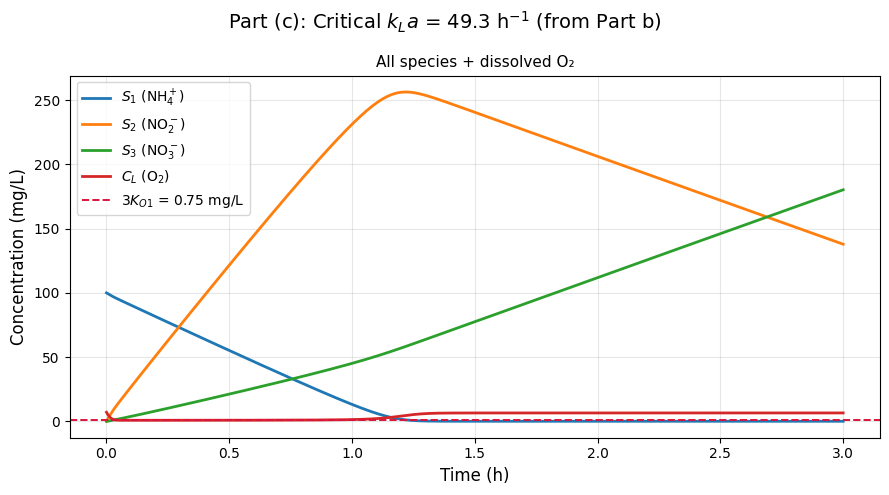


Summary:
  - S1 depleted (< 1.0 mg/L) at t ≈ 60.5 min (1.0088 h) without O₂ limitation.
  - Critical k_La = 49.3 h⁻¹ keeps C_L above 3·K_O1 = 0.75 mg/L throughout.


In [25]:
# Solve for both kLa cases
kLa_no_lim = 1000.0          # h⁻¹ — virtually no O₂ limitation
# kLa_critical comes from Part (b) sweep above

t_span_c = (0, 3)
t_eval_c = np.linspace(0, 3, 5000)

sol_nl = simulate(kLa_no_lim, t_end=3.0, n_points=5000)
sol_cr = simulate(kLa_critical, t_end=3.0, n_points=5000)

# Find time when S1 -> 0 in the no-limitation case
threshold = 1.0   # mg/L — considered "depleted"
idx_zero  = np.where(sol_nl.y[0] < threshold)[0]
if len(idx_zero) > 0:
    t_zero = sol_nl.t[idx_zero[0]]
    print(f"S1 (NH4+) reaches ~0 mg/L at t ≈ {t_zero:.4f} h  (no O₂ limitation)")
else:
    t_zero = None
    print("S1 did not reach 0 within the simulated time – extend t_span.")

# Labels and colours shared by both figures 
labels = [r'$S_1$ (NH$_4^+$)', r'$S_2$ (NO$_2^-$)',
          r'$S_3$ (NO$_3^-$)', r'$C_L$ (O$_2$)']
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

# Plot 1: No oxygen limitation (kLa = 1000 h⁻¹) 
fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle(r'Part (c): No oxygen limitation ($k_La = 1000\ h^{-1}$)', fontsize=14)

for k, (lbl, col) in enumerate(zip(labels, colors)):
    ax.plot(sol_nl.t, sol_nl.y[k], color=col, lw=2, label=lbl)

ax.axhline(3 * KO1, color='crimson', ls='--', lw=1.4,
           label=rf'$3K_{{O1}}$ = {3*KO1} mg/L')
if t_zero is not None:
    ax.axvline(t_zero, color='black', ls='--', lw=1.4,
               label=f'S1 ~ 0 at t = {t_zero:.3f} h')

ax.set_xlabel('Time (h)', fontsize=12)
ax.set_ylabel('Concentration (mg/L)', fontsize=12)
ax.set_title(r'All species + dissolved O₂', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 2: Critical kLa from Part (b)
fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle(rf'Part (c): Critical $k_La$ = {kLa_critical:.1f} h$^{{-1}}$ (from Part b)',
             fontsize=14)

for k, (lbl, col) in enumerate(zip(labels, colors)):
    ax.plot(sol_cr.t, sol_cr.y[k], color=col, lw=2, label=lbl)

ax.axhline(3 * KO1, color='crimson', ls='--', lw=1.4,
           label=rf'$3K_{{O1}}$ = {3*KO1} mg/L')

ax.set_xlabel('Time (h)', fontsize=12)
ax.set_ylabel('Concentration (mg/L)', fontsize=12)
ax.set_title(r'All species + dissolved O₂', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

if t_zero is not None:
    print(f"\nSummary:")
    print(f"  - S1 depleted (< {threshold} mg/L) at t ≈ {t_zero*60:.1f} min ({t_zero:.4f} h) without O₂ limitation.")
    print(f"  - Critical k_La = {kLa_critical:.1f} h⁻¹ keeps C_L above 3·K_O1 = {3*KO1} mg/L throughout.")
